In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from tensorflow.keras.models import load_model
from tensorflow.keras.metrics import MeanSquaredError
from tensorflow.keras.saving import register_keras_serializable

# Define and register the custom metric
@register_keras_serializable()
def mse(y_true, y_pred):
    return MeanSquaredError()(y_true, y_pred)

# Load the pre-trained model with the custom objects
model = load_model('air_quality_model.h5', custom_objects={'mse': mse})
model.summary()
scaler = joblib.load('air_quality_scaler.joblib')

2024-12-21 13:47:22.042982: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-12-21 13:47:22.177737: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1734763642.250593    1938 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1734763642.268423    1938 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-21 13:47:22.402465: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,675 (127.64 KB)

 Trainable params: 32,673 (127.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [2]:
def evaluate_air_quality(co_level):
    if co_level < 4.4:
        return "Good"
    elif co_level < 9.4:
        return "Moderate"
    elif co_level < 12.4:
        return "Unhealthy for Sensitive Groups"
    elif co_level < 15.4:
        return "Unhealthy"
    else:
        return "Very Unhealthy"

In [3]:
def predict_air_quality(model, scaler, data, sequence_length=1):
    """
    Predict a sequence of air quality values based on the provided data.

    Parameters:
    - model: Trained model for prediction.
    - scaler: Scaler used to normalize the data.
    - data: DataFrame containing the conditions for prediction.
    - sequence_length: Number of past time steps to consider for each prediction.

    Returns:
    - predictions: List of predicted air quality values.
    - statuses: List of air quality statuses corresponding to the predictions.
    """
    import numpy as np

    # Ensure the data contains only numerical values
    data = data.select_dtypes(include=[np.number])

    # Reorder columns to match the scaler's expected order
    if hasattr(scaler, "feature_names_in_"):
        expected_features = scaler.feature_names_in_
        data = data[expected_features]

    # Scale the input data
    scaled_data = scaler.transform(data)
    print(len(scaled_data))

    # Ensure there is enough data for prediction
    if len(scaled_data) < sequence_length:
        raise ValueError(
            f"Insufficient data: Only {len(scaled_data)} rows available, but sequence_length is {sequence_length}"
        )

    predictions = []
    statuses = []

    # Iterate through the data to predict a sequence
    for i in range(sequence_length, len(scaled_data) + 1):
        # Extract the current window of data
        sequence = scaled_data[i - sequence_length:i].reshape(1, sequence_length, -1)

        # Predict the CO level
        predicted_co = model.predict(sequence)[0][0]

        # Reverse scaling for interpretation
        predicted_co = scaler.inverse_transform(
            [[predicted_co] + [0] * (scaled_data.shape[1] - 1)]
        )[0][0]

        # Evaluate air quality status
        quality_status = evaluate_air_quality(predicted_co)

        # Store the prediction and status
        predictions.append(predicted_co)
        statuses.append(quality_status)

    return predictions, statuses

In [4]:
def generate_test_data_24():
    """
    Generate 24 rows of air quality test data with minimal fluctuation between consecutive rows.

    Returns:
    - DataFrame: 24 rows of generated air quality data.
    """
    import numpy as np
    import pandas as pd
    from datetime import datetime, timedelta

    # Fixed starting date and time
    start_date = datetime(2023, 1, 1, 0, 0)

    # Generate baseline data for each column
    baseline_data = {
        'C6H6(GT)': np.random.uniform(5, 15),
        'CO(GT)': np.random.uniform(2, 8),
        'NMHC(GT)': np.random.uniform(50, 90),
        'NO2(GT)': np.random.uniform(60, 120),
        'NOx(GT)': np.random.uniform(100, 180),
        'PT08.S1(CO)': np.random.uniform(900, 1100),
        'PT08.S2(NMHC)': np.random.uniform(800, 1000),
        'PT08.S3(NOx)': np.random.uniform(900, 1100),
        'PT08.S4(NO2)': np.random.uniform(1000, 1200),
        'PT08.S5(O3)': np.random.uniform(900, 1100),
        'T': np.random.uniform(15, 25),
        'RH': np.random.uniform(40, 70),
        'AH': np.random.uniform(1.0, 1.5)
    }

    # Define fluctuation range for each column
    fluctuation_range = {
        'C6H6(GT)': 0.5,
        'CO(GT)': 0.2,
        'NMHC(GT)': 2.0,
        'NO2(GT)': 3.0,
        'NOx(GT)': 5.0,
        'PT08.S1(CO)': 10.0,
        'PT08.S2(NMHC)': 10.0,
        'PT08.S3(NOx)': 10.0,
        'PT08.S4(NO2)': 10.0,
        'PT08.S5(O3)': 10.0,
        'T': 0.5,
        'RH': 1.0,
        'AH': 0.05
    }

    # Generate 24 rows of data
    rows = []
    for i in range(24):
        row = {}
        for key in baseline_data:
            # Generate values with minimal fluctuation from the baseline
            fluctuation = np.random.uniform(-fluctuation_range[key], fluctuation_range[key])
            row[key] = baseline_data[key] + fluctuation

        # Add date and time
        current_time = start_date + timedelta(hours=i)
        row['Date'] = current_time.strftime('%d/%m/%Y')
        row['Time'] = current_time.strftime('%H.%M.%S')

        rows.append(row)

    return pd.DataFrame(rows)

In [5]:
def generate_single_test_data():
    # Fixed date and time for the single sample
    date = datetime(2023, 1, 1, 0, 0)
    
    # Generate random data for each column
    data = {
        'Date': date.strftime('%d/%m/%Y'),
        'Time': date.strftime('%H.%M.%S'),
        'C6H6(GT)': np.random.uniform(0, 20),  # Benzene's expected format
        'CO(GT)': np.random.uniform(0, 10),
        'NMHC(GT)': np.random.uniform(0, 100),
        'NO2(GT)': np.random.uniform(0, 150),
        'NOx(GT)': np.random.uniform(0, 200),
        'PT08.S1(CO)': np.random.uniform(800, 1200),
        'PT08.S2(NMHC)': np.random.uniform(700, 1100),
        'PT08.S3(NOx)': np.random.uniform(800, 1200),
        'PT08.S4(NO2)': np.random.uniform(900, 1300),
        'PT08.S5(O3)': np.random.uniform(800, 1200),
        'T': np.random.uniform(10, 30),
        'RH': np.random.uniform(20, 80),
        'AH': np.random.uniform(0.5, 2.0)
    }
    
    return pd.DataFrame([data])

In [6]:
# def generate_predictions_and_plot(model, scaler, input_data, sequence_length=1):
#     """
#     Generate predictions for air quality and plot the results.

#     Parameters:
#         model: Trained model for air quality prediction.
#         scaler: Pre-trained scaler for preprocessing.
#         input_data: Pandas DataFrame of input data (must match expected structure).
#         sequence_length: Sequence length expected by the model.

#     Returns:
#         None. Displays a plot of predictions.
#     """
#     # Debugging step: Check the input data
#     print("Input data:")
#     print(input_data.head())

#     timestamps = input_data.index if 'datetime' in input_data.columns else range(len(input_data))
#     predicted_values = []
#     quality_statuses = []

#     for i in range(sequence_length, len(input_data)):
#         # Extract the current sequence for prediction
#         sequence_data = input_data
#         try:
#             predicted_co, quality_status = predict_air_quality(model, scaler, sequence_data)
#             predicted_values.append(predicted_co)
#             quality_statuses.append(quality_status)
#         except Exception as e:
#             print(f"Error during prediction at index {i}: {e}")
#             predicted_values.append(None)
#             quality_statuses.append(None)

#     # Debugging step: Check the predicted values
#     print("Predicted values:")
#     print(predicted_values)

#     # Plotting predictions
#     plt.figure(figsize=(12, 6))
#     plt.plot(timestamps[sequence_length:], predicted_values, label="Predicted CO Levels", color="blue")
#     plt.title("Predicted Air Quality Over Time")
#     plt.xlabel("Time")
#     plt.ylabel("CO Levels")
#     plt.grid(True)
#     plt.legend()
#     plt.show()

#     # Display the last few statuses for reference
#     for t, value, status in zip(timestamps[-5:], predicted_values[-5:], quality_statuses[-5:]):
#         print(f"Time: {t}, Predicted CO: {value:.2f}, Quality: {status}")

In [7]:
data =[
    {"Date": "21/03/2004", "Time": "16.00.00", "CO(GT)": 1.9, "PT08.S1(CO)": 1208, "NMHC(GT)": -200, "C6H6(GT)": 6.9, "PT08.S2(NMHC)": 853, "NOx(GT)": 98, "PT08.S3(NOx)": 1060, "NO2(GT)": 89, "PT08.S4(NO2)": 1506, "PT08.S5(O3)": 647, "T": 20.3, "RH": 38.0, "AH": 0.8942},
    {"Date": "21/03/2004", "Time": "17.00.00", "CO(GT)": 2.3, "PT08.S1(CO)": 1306, "NMHC(GT)": -200, "C6H6(GT)": 9.0, "PT08.S2(NMHC)": 938, "NOx(GT)": 132, "PT08.S3(NOx)": 961, "NO2(GT)": 105, "PT08.S4(NO2)": 1607, "PT08.S5(O3)": 762, "T": 19.4, "RH": 41.3, "AH": 0.9206},
    {"Date": "21/03/2004", "Time": "18.00.00", "CO(GT)": 3.8, "PT08.S1(CO)": 1546, "NMHC(GT)": -200, "C6H6(GT)": 15.1, "PT08.S2(NMHC)": 1151, "NOx(GT)": 173, "PT08.S3(NOx)": 769, "NO2(GT)": 116, "PT08.S4(NO2)": 1874, "PT08.S5(O3)": 1122, "T": 18.5, "RH": 43.8, "AH": 0.9252},
    {"Date": "21/03/2004", "Time": "19.00.00", "CO(GT)": 3.5, "PT08.S1(CO)": 1501, "NMHC(GT)": -200, "C6H6(GT)": 12.6, "PT08.S2(NMHC)": 1071, "NOx(GT)": 185, "PT08.S3(NOx)": 823, "NO2(GT)": 119, "PT08.S4(NO2)": 1744, "PT08.S5(O3)": 1130, "T": 17.8, "RH": 48.1, "AH": 0.9689},
    {"Date": "21/03/2004", "Time": "20.00.00", "CO(GT)": 4.3, "PT08.S1(CO)": 1605, "NMHC(GT)": -200, "C6H6(GT)": 15.1, "PT08.S2(NMHC)": 1153, "NOx(GT)": 266, "PT08.S3(NOx)": 769, "NO2(GT)": 144, "PT08.S4(NO2)": 1840, "PT08.S5(O3)": 1637, "T": 17.9, "RH": 46.9, "AH": 0.9520},
    {"Date": "21/03/2004", "Time": "21.00.00", "CO(GT)": 2.8, "PT08.S1(CO)": 1316, "NMHC(GT)": -200, "C6H6(GT)": 9.9, "PT08.S2(NMHC)": 974, "NOx(GT)": 188, "PT08.S3(NOx)": 883, "NO2(GT)": 123, "PT08.S4(NO2)": 1673, "PT08.S5(O3)": 1272, "T": 17.4, "RH": 49.1, "AH": 0.9688},
    {"Date": "21/03/2004", "Time": "22.00.00", "CO(GT)": 1.9, "PT08.S1(CO)": 1195, "NMHC(GT)": -200, "C6H6(GT)": 8.0, "PT08.S2(NMHC)": 898, "NOx(GT)": 122, "PT08.S3(NOx)": 933, "NO2(GT)": 105, "PT08.S4(NO2)": 1594, "PT08.S5(O3)": 1098, "T": 17.0, "RH": 51.7, "AH": 0.9914},
    {"Date": "21/03/2004", "Time": "23.00.00", "CO(GT)": 1.9, "PT08.S1(CO)": 1211, "NMHC(GT)": -200, "C6H6(GT)": 7.9, "PT08.S2(NMHC)": 896, "NOx(GT)": 112, "PT08.S3(NOx)": 920, "NO2(GT)": 93, "PT08.S4(NO2)": 1624, "PT08.S5(O3)": 1066, "T": 16.4, "RH": 55.1, "AH": 1.0198},
    {"Date": "22/03/2004", "Time": "00.00.00", "CO(GT)": 1.7, "PT08.S1(CO)": 1161, "NMHC(GT)": -200, "C6H6(GT)": 6.1, "PT08.S2(NMHC)": 815, "NOx(GT)": 93, "PT08.S3(NOx)": 995, "NO2(GT)": 86, "PT08.S4(NO2)": 1582, "PT08.S5(O3)": 909, "T": 16.1, "RH": 60.0, "AH": 1.0919},
    {"Date": "22/03/2004", "Time": "01.00.00", "CO(GT)": 1.5, "PT08.S1(CO)": 1095, "NMHC(GT)": -200, "C6H6(GT)": 5.1, "PT08.S2(NMHC)": 767, "NOx(GT)": 74, "PT08.S3(NOx)": 1050, "NO2(GT)": 76, "PT08.S4(NO2)": 1547, "PT08.S5(O3)": 818, "T": 15.8, "RH": 60.5, "AH": 1.0805},
    {"Date": "22/03/2004", "Time": "02.00.00", "CO(GT)": 0.6, "PT08.S1(CO)": 897, "NMHC(GT)": -200, "C6H6(GT)": 1.7, "PT08.S2(NMHC)": 563, "NOx(GT)": 23, "PT08.S3(NOx)": 1417, "NO2(GT)": 33, "PT08.S4(NO2)": 1355, "PT08.S5(O3)": 472, "T": 16.3, "RH": 57.0, "AH": 1.0491},
    {"Date": "22/03/2004", "Time": "03.00.00", "CO(GT)": 0.4, "PT08.S1(CO)": 842, "NMHC(GT)": -200, "C6H6(GT)": 0.7, "PT08.S2(NMHC)": 468, "NOx(GT)": -200, "PT08.S3(NOx)": 1813, "NO2(GT)": -200, "PT08.S4(NO2)": 1274, "PT08.S5(O3)": 394, "T": 16.9, "RH": 53.9, "AH": 1.0309},
    {"Date": "22/03/2004", "Time": "04.00.00", "CO(GT)": -200, "PT08.S1(CO)": 854, "NMHC(GT)": -200, "C6H6(GT)": 0.8, "PT08.S2(NMHC)": 481, "NOx(GT)": 17, "PT08.S3(NOx)": 1756, "NO2(GT)": 27, "PT08.S4(NO2)": 1304, "PT08.S5(O3)": 396, "T": 16.1, "RH": 55.9, "AH": 1.0153},
    {"Date": "22/03/2004", "Time": "05.00.00", "CO(GT)": 0.3, "PT08.S1(CO)": 845, "NMHC(GT)": -200, "C6H6(GT)": 0.7, "PT08.S2(NMHC)": 472, "NOx(GT)": 15, "PT08.S3(NOx)": 1786, "NO2(GT)": 23, "PT08.S4(NO2)": 1278, "PT08.S5(O3)": 378, "T": 16.5, "RH": 53.9, "AH": 1.0049},
    {"Date": "22/03/2004", "Time": "06.00.00", "CO(GT)": 0.6, "PT08.S1(CO)": 942, "NMHC(GT)": -200, "C6H6(GT)": 2.0, "PT08.S2(NMHC)": 586, "NOx(GT)": 41, "PT08.S3(NOx)": 1480, "NO2(GT)": 46, "PT08.S4(NO2)": 1373, "PT08.S5(O3)": 432, "T": 16.4, "RH": 54.0, "AH": 0.9979},
    {"Date": "22/03/2004", "Time": "07.00.00", "CO(GT)": 1.2, "PT08.S1(CO)": 1090, "NMHC(GT)": -200, "C6H6(GT)": 5.1, "PT08.S2(NMHC)": 768, "NOx(GT)": 86, "PT08.S3(NOx)": 1072, "NO2(GT)": 76, "PT08.S4(NO2)": 1538, "PT08.S5(O3)": 699, "T": 15.7, "RH": 57.6, "AH": 1.0195},
    {"Date": "22/03/2004", "Time": "08.00.00", "CO(GT)": 3.6, "PT08.S1(CO)": 1514, "NMHC(GT)": -200, "C6H6(GT)": 17.7, "PT08.S2(NMHC)": 1230, "NOx(GT)": 226, "PT08.S3(NOx)": 732, "NO2(GT)": 116, "PT08.S4(NO2)": 1996, "PT08.S5(O3)": 1252, "T": 15.8, "RH": 53.7, "AH": 0.9571},
    {"Date": "22/03/2004", "Time": "09.00.00", "CO(GT)": 3.7, "PT08.S1(CO)": 1379, "NMHC(GT)": -200, "C6H6(GT)": 18.4, "PT08.S2(NMHC)": 1252, "NOx(GT)": 214, "PT08.S3(NOx)": 711, "NO2(GT)": 115, "PT08.S4(NO2)": 1962, "PT08.S5(O3)": 1237, "T": 17.4, "RH": 42.1, "AH": 0.8281},
    {"Date": "22/03/2004", "Time": "10.00.00", "CO(GT)": 1.8, "PT08.S1(CO)": 1074, "NMHC(GT)": -200, "C6H6(GT)": 6.9, "PT08.S2(NMHC)": 854, "NOx(GT)": 115, "PT08.S3(NOx)": 1032, "NO2(GT)": 83, "PT08.S4(NO2)": 1484, "PT08.S5(O3)": 772, "T": 17.9, "RH": 38.4, "AH": 0.7793},
    {"Date": "22/03/2004", "Time": "11.00.00", "CO(GT)": 1.6, "PT08.S1(CO)": 1090, "NMHC(GT)": -200, "C6H6(GT)": 7.3, "PT08.S2(NMHC)": 868, "NOx(GT)": 124, "PT08.S3(NOx)": 1026, "NO2(GT)": 87, "PT08.S4(NO2)": 1509, "PT08.S5(O3)": 766, "T": 18.5, "RH": 36.7, "AH": 0.7764},
    {"Date": "22/03/2004", "Time": "12.00.00", "CO(GT)": 1.9, "PT08.S1(CO)": 1110, "NMHC(GT)": -200, "C6H6(GT)": 9.6, "PT08.S2(NMHC)": 964, "NOx(GT)": 122, "PT08.S3(NOx)": 947, "NO2(GT)": 90, "PT08.S4(NO2)": 1577, "PT08.S5(O3)": 829, "T": 21.0, "RH": 29.6, "AH": 0.7263},
    {"Date": "22/03/2004", "Time": "13.00.00", "CO(GT)": 2.0, "PT08.S1(CO)": 1102, "NMHC(GT)": -200, "C6H6(GT)": 10.4, "PT08.S2(NMHC)": 994, "NOx(GT)": 107, "PT08.S3(NOx)": 955, "NO2(GT)": 87, "PT08.S4(NO2)": 1599, "PT08.S5(O3)": 783, "T": 21.3, "RH": 28.1, "AH": 0.7067},
    {"Date": "22/03/2004", "Time": "14.00.00", "CO(GT)": 2.2, "PT08.S1(CO)": 1100, "NMHC(GT)": -200, "C6H6(GT)": 11.2, "PT08.S2(NMHC)": 1021, "NOx(GT)": 133, "PT08.S3(NOx)": 952, "NO2(GT)": 99, "PT08.S4(NO2)": 1607, "PT08.S5(O3)": 822, "T": 21.3, "RH": 26.1, "AH": 0.6539},
    {"Date": "22/03/2004", "Time": "15.00.00", "CO(GT)": 2.1, "PT08.S1(CO)": 1094, "NMHC(GT)": -200, "C6H6(GT)": 10.7, "PT08.S2(NMHC)": 1003, "NOx(GT)": 130, "PT08.S3(NOx)": 965, "NO2(GT)": 99, "PT08.S4(NO2)": 1574, "PT08.S5(O3)": 813, "T": 21.3, "RH": 26.8, "AH": 0.6681},
]


1


I0000 00:00:1734763650.050575   10879 cuda_dnn.cc:529] Loaded cuDNN version 90300


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 563ms/step
Predicted CO level: 2.47 ppm
Air quality: Good

1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted CO level: 3.11 ppm
Air quality: Good

1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Predicted CO level: 4.65 ppm
Air quality: Moderate

1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicted CO level: 4.31 ppm
Air quality: Good

1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Predicted CO level: 4.94 ppm
Air quality: Moderate

1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicted CO level: 3.54 ppm
Air quality: Good

1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Predicted CO level: 2.45 ppm
Air quality: Good

1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Predicted CO level: 2.44 ppm
Air quality: Good

1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Predicted CO level: 2.04 ppm
Air quality: Good

1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted CO level: 1.68 ppm
Air quality: Good

1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predicted CO level: 0.81 ppm
Air quality: Good

1
1/1 ━━━━━━━━━━━━━━━━━━━

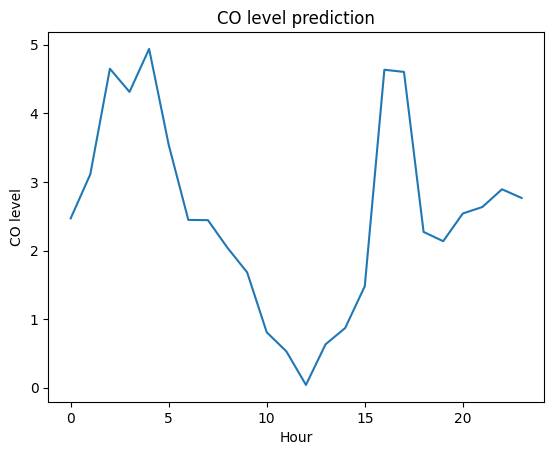

/tmp/ipykernel_1938/3187761587.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


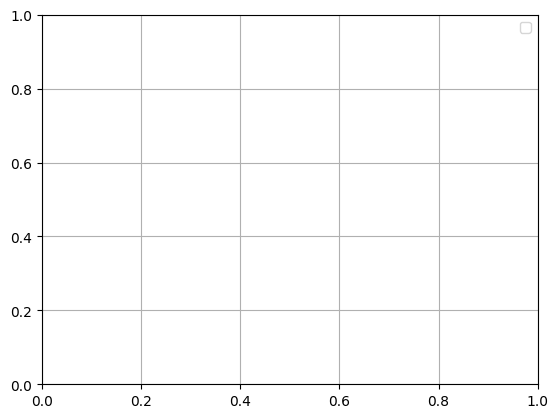

In [8]:
input_data = pd.DataFrame(data)
# input_data1 = generate_single_test_data()
# input_data.to_csv('test_air_quality.csv', sep=';', decimal=',', index=False)

# print((input_data))



# turn input data to numpy array
# input_data = input_data.to_numpy()
# print(pd.DataFrame([input_data.iloc[0].T]))

# print(type(input_data1))
# print(input_data1)

# co_level, quality = predict_air_quality(model, scaler, pd.DataFrame([input_data.iloc[0].T]))
# print(co_level)

#make array for plotting

data = []
hour = list(range(24))

for i in range(24):
    co_level, quality = predict_air_quality(model, scaler, pd.DataFrame([input_data.iloc[i].T]))
    print(f"Predicted CO level: {co_level[0]:.2f} ppm")
    print(f"Air quality: {quality[0]}")
    print()
    data.append(co_level[0])

plt.plot(hour, data)
plt.xlabel('Hour')
plt.ylabel('CO level')
plt.title('CO level prediction')
plt.show()
plt.legend()
plt.grid(True)

    


# for i in range(24):
#     co_level, quality = predict_air_quality(model, scaler, input_data[i])
#     print(f"Predicted CO level: {co_level:.2f} ppm")
#     print(f"Air quality: {quality}")
#     print()
    





# print('plotted')

# Generate predictions and plot the results
# generate_predictions_and_plot(model, scaler, input_data, sequence_length=10)